# Library import

In [3]:
import pandas as pd
import numpy as np
import gc
from datetime import datetime as dt
from datetime import date
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

import hydroeval as he
from lumod import tools, MonteCarlo
from lumod.models import HBV

# Получение данных о расходе по индексу

In [4]:
def get_q_data_on_index(index_hydro, hydro_data):
    hydro_data = hydro_data.loc[hydro_data["index"] == index_hydro]
    hydro_data['Date'] = pd.to_datetime(hydro_data['date'])
    hydro_data.set_index("date", inplace=True)
    hydro_data = hydro_data.rename(columns={"q": "qt"})
    recharge_data = hydro_data["qt"]
    return recharge_data

# Получените данных метео по индексу

In [5]:
def get_hydro_data_on_index(index_hydro):
    hydro_meteo_data = pd.read_excel(f"data/catchiments/{index_hydro}.xlsx")
    hydro_meteo_data['Date'] = pd.to_datetime(hydro_meteo_data['Date'])
    hydro_meteo_data['Prec'] = hydro_meteo_data['Prec'].fillna(0)
    hydro_meteo_data.set_index("Date", inplace=True)
    hydro_meteo_data = hydro_meteo_data.rename(columns={"Temp": "tmean", "Prec": "prec"})
    hydro_meteo_data = hydro_meteo_data[["prec", "tmean"]]
    return hydro_meteo_data

# Формирование данных о площади и широте по индексу

In [6]:
def get_post_info(df, index):
    df = df.loc[df["ids"] == index]
    area = float(df['Площ'])
    lat = float(df['lat'])
    return area, lat

# Чтение исходников

In [7]:
hydro_q_data = pd.read_excel("data/qtpet_pairs.xlsx")
hydro_post_data = pd.read_excel("data/hydrology_stations.xlsx")

# Задаем индекс водосбора

In [8]:
index_hydro = 11124

In [9]:
hydro_q_data = get_q_data_on_index(index_hydro, hydro_q_data)

In [10]:
hydro_data = get_hydro_data_on_index(index_hydro)
hydro_data["qt"] = hydro_q_data

# Задаем даты начала(с разогревом) и конца калибровки

In [11]:
cal_date_start_minus_one = date(2006, 1, 1)
cal_date_end = date(2016, 12, 31)

# Проверяем на пропуски в данных

In [12]:
print(list(hydro_data.asfreq(freq='D').index.difference(hydro_data.index)))

[Timestamp('2003-11-20 00:00:00')]


# Калибровка

In [13]:
area, lat = get_post_info(hydro_post_data, index_hydro)

In [45]:
model_HBV = HBV(
    area = area,
    lat = lat,
)
xobs = hydro_data[["qt"]]

bounds =  { 
    "tthres": (-2, 5),
    "dd": (1, 6),
    "beta": (1, 6),
    "fc": (0, 1000),
    "k0": (0.01, 3),
    "k1": (0.001, 2),
    "k2": (0.0001, 0.01),
    "kp": (0, 2), # recession coefficient of percolation (1/d)
    "snow0": (-10, 100),
    "w01": (10, 1000),
    "w02": (10, 1000),
}
score1 = {
    "var": "qt",
    "metric": "nse",
    "weight": 1
}
scores = [score1]

mc_res = MonteCarlo(
    model_HBV,
    hydro_data[cal_date_start_minus_one:cal_date_end],
    bounds,
    numsimul=250000,
    save_vars=["qt"],
    xobs=xobs,
    scores=scores,
    keep_best=1,
    start=cal_date_start_minus_one,
    end=cal_date_end
)
gc.collect()

Progress: |██████████████████████████████████████████████████| 100.0% Complete


0

In [46]:
parameters = mc_res["parameters"].to_dict(orient="index")[1]

In [47]:
parameters

{'maxbas': 3.0,
 'tthres': 0.35861632227897644,
 'dd': 3.861358880996704,
 'cevp': 2.0,
 'cevpam': 1.0,
 'cevpph': 0.0,
 'beta': 3.4844114780426025,
 'fc': 893.75634765625,
 'pwp': 0.800000011920929,
 'k0': 0.02021735906600952,
 'k1': 0.0440429262816906,
 'k2': 0.0034831722732633352,
 'kp': 0.03896494209766388,
 'lthres': 50.0,
 'snow0': 55.48601150512695,
 's0': 0.5,
 'w01': 21.2281551361084,
 'w02': 525.5758056640625}

# Запускем расчет на параметрах калибровки и собираем статистику

In [14]:
def calibration(df, start_c, end_c, area, lat, parameters_calibration):
    model_HBV = HBV(area=area, lat=lat, params=parameters_calibration)

    sim_cal = model_HBV.run(df, start=start_c, end=end_c)
    metrics_cal = tools.metrics.summary(df["qt"], sim_cal["qt"])
    print("Calibration period")
    
    tools.plots.model_evaluation(df["prec"], df["qt"], sim_cal["qt"],
                                 start=start_c, end=end_c)

    return metrics_cal, sim_cal

Calibration period


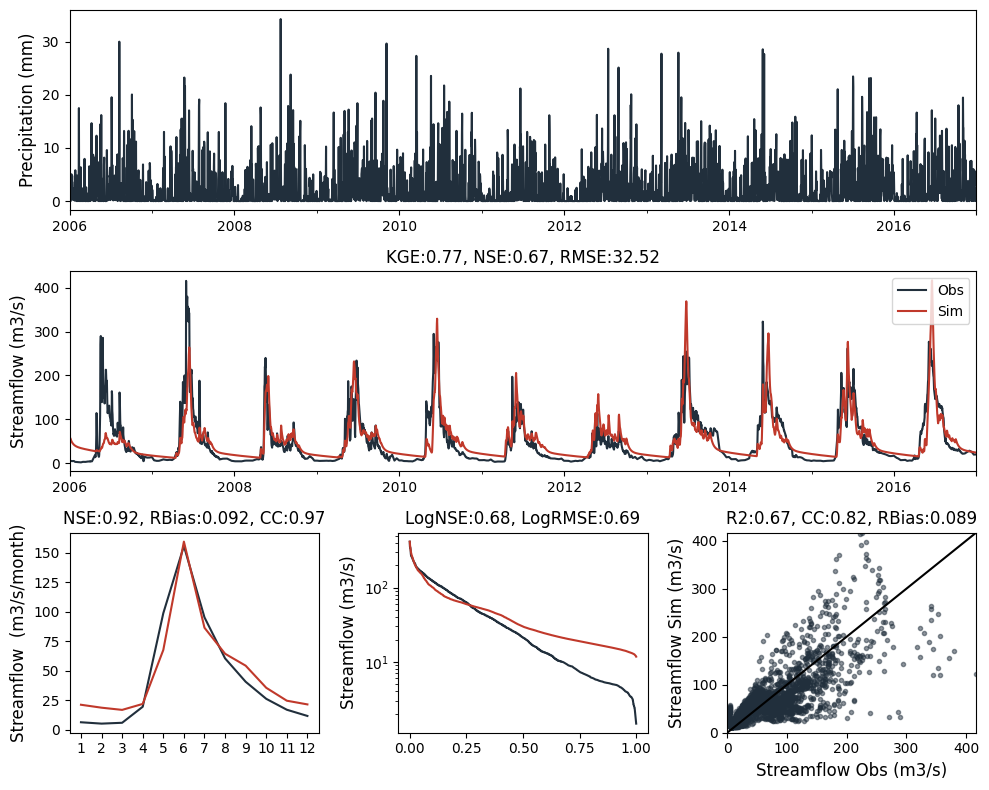

In [15]:
metrics, cal= calibration(hydro_data, cal_date_start_minus_one, cal_date_end, area, lat, p_good)

# Форматируем результаты калибровки

In [16]:
df_hydro_calibration = pd.DataFrame()
df_hydro_calibration["Observed values"] =  hydro_data.loc[cal_date_start_minus_one:cal_date_end].qt
df_hydro_calibration["Simulated values"] =  cal.loc[cal_date_start_minus_one:cal_date_end].qt
df_hydro_calibration = df_hydro_calibration[cal_date_start_minus_one.replace(year=cal_date_start_minus_one.year + 1):]
df_hydro_calibration = df_hydro_calibration.dropna()
df_hydro_calibration = df_hydro_calibration[df_hydro_calibration["Simulated values"] != np.inf]
df_hydro_calibration = df_hydro_calibration[df_hydro_calibration["Simulated values"] > -np.inf]

In [31]:
df_hydro_calibration.to_excel(f"result/con/{hydro_post_data.loc[hydro_post_data["ids"] == index_hydro]["name"].values[0]}({index_hydro}) NSE MC ДЛЯ СТАТЬИ КАЛИБРОВКА РЕОНАЛИЗ 2006 по 2016.xlsx")

#  Вывод метрик по калибровке

In [18]:

metrics_calibration = {
    "NSE" : round(float((he.evaluator(he.nse, df_hydro_calibration["Simulated values"].values, df_hydro_calibration["Observed values"].values))[0]), 2), 
    "KGE": round(float((he.evaluator(he.kge, df_hydro_calibration["Simulated values"].values, df_hydro_calibration["Observed values"].values))[0]), 2),
    "RMSE": round(root_mean_squared_error(df_hydro_calibration["Observed values"].values, df_hydro_calibration["Simulated values"].values), 2),
    "MAE": round(mean_absolute_error(df_hydro_calibration["Observed values"].values, df_hydro_calibration["Simulated values"].values), 2),
}
metrics_calibration = pd.DataFrame.from_dict([metrics_calibration])
metrics_calibration

,NSE,KGE,RMSE,MAE
0,0.71,0.8,30.08,19.67


# Визуализация калибровочного периода по каждому году

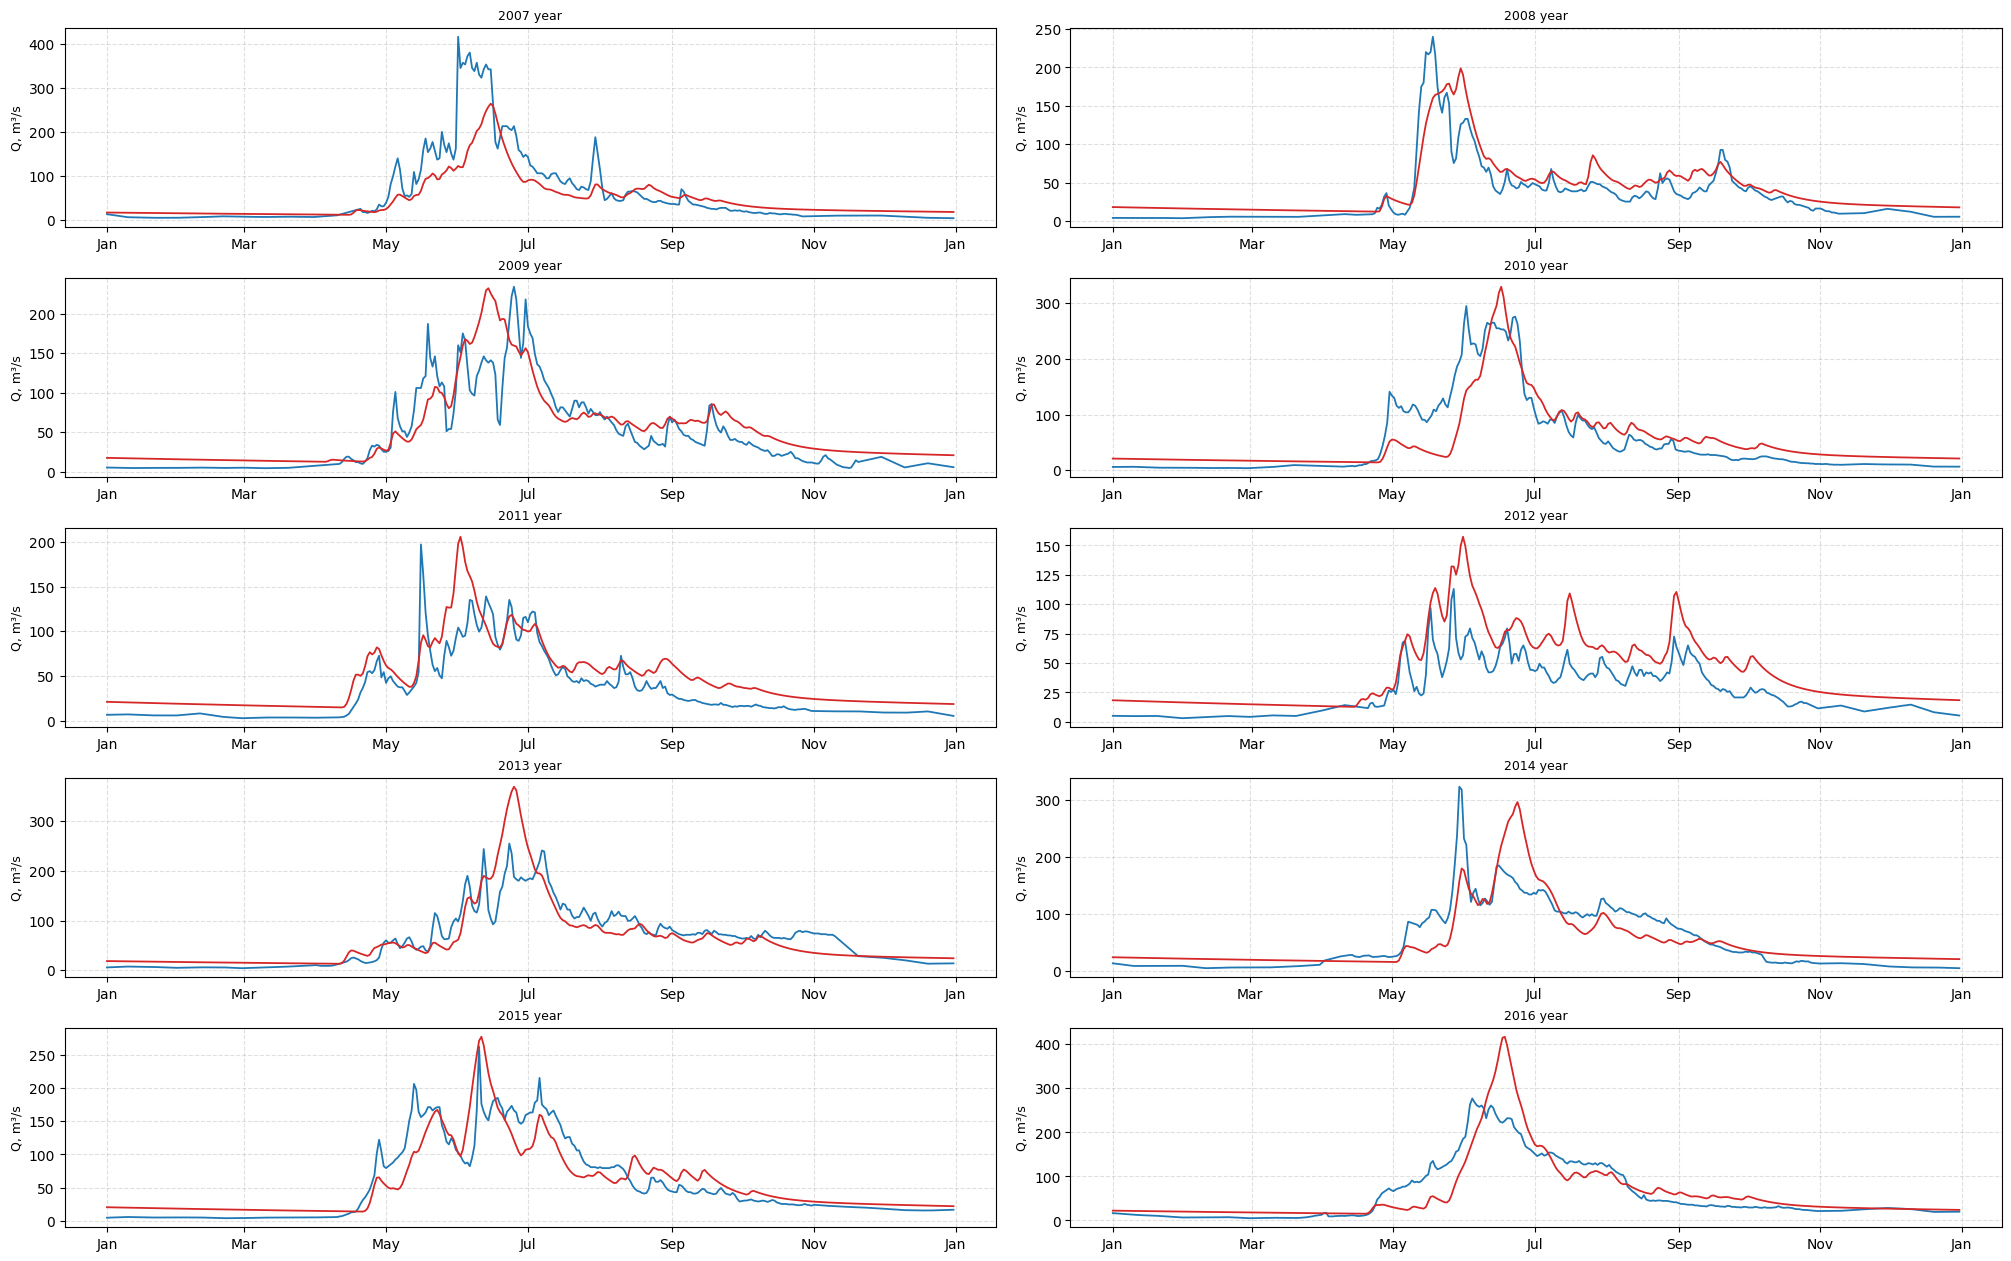

In [19]:
numeric_cols = ['Observed values', 'Simulated values']
years = sorted(df_hydro_calibration.index.year.unique())

# Оптимальное количество колонок
ncols = 2
nrows = (len(years) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, 
    figsize=(20, nrows*2.5), 
    constrained_layout=True
)

# fig.suptitle('Калибровка ЭКОМАГ', fontsize=16, y=1.02)
date_format = mdates.DateFormatter("%b")

# Заглушки для легенды
lines = []
for col in numeric_cols:
    line, = axes.flat[0].plot([], [], label=col)
    lines.append(line)

# Отрисовка графиков
for i, year in enumerate(years):
    ax = axes.flat[i]
    year_data = df_hydro_calibration[df_hydro_calibration.index.year == year]

    ax.plot(year_data['Observed values'], color="#1f77b4", linewidth=1.3)
    ax.plot(year_data['Simulated values'], color="#d62728", linewidth=1.3)
    ax.set_ylabel("Q, m³/s", fontsize=9)
    ax.set_title(f'{year} year', fontsize=9)
    ax.xaxis.set_major_formatter(date_format)
    ax.grid(True, linestyle='--', alpha=0.4)

# Убираем пустые оси
for j in range(i+1, nrows*ncols):
    fig.delaxes(axes.flat[j])

# Легенду переносим вниз
# fig.legend(
#     handles=lines,
#     labels=numeric_cols,
#     loc='upper left',
#     ncol=2,
#     frameon=False,
#     fontsize=12
# )
# Добавляем отступ снизу под легенду
plt.subplots_adjust(bottom=0.10)

# plt.savefig("annual_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Расчет на валидационном периоде

In [20]:
def validation(df, start_c, end_c, area, lat, parameters_calibration):
    model_HBV = HBV(area=area, lat=lat, params=parameters_calibration)

    sim_cal = model_HBV.run(df, start=start_c, end=end_c)
    metrics_cal = tools.metrics.summary(df["qt"], sim_cal["qt"])
    print("validation period")
    
    tools.plots.model_evaluation(df["prec"], df["qt"], sim_cal["qt"],
                                 start=start_c, end=end_c)

    return metrics_cal, sim_cal

# Даты начала(минус один) и конца валидации

In [21]:
val_date_start_minus_one = date(2016, 1, 1)
val_date_end = date(2021, 12, 31)

validation period


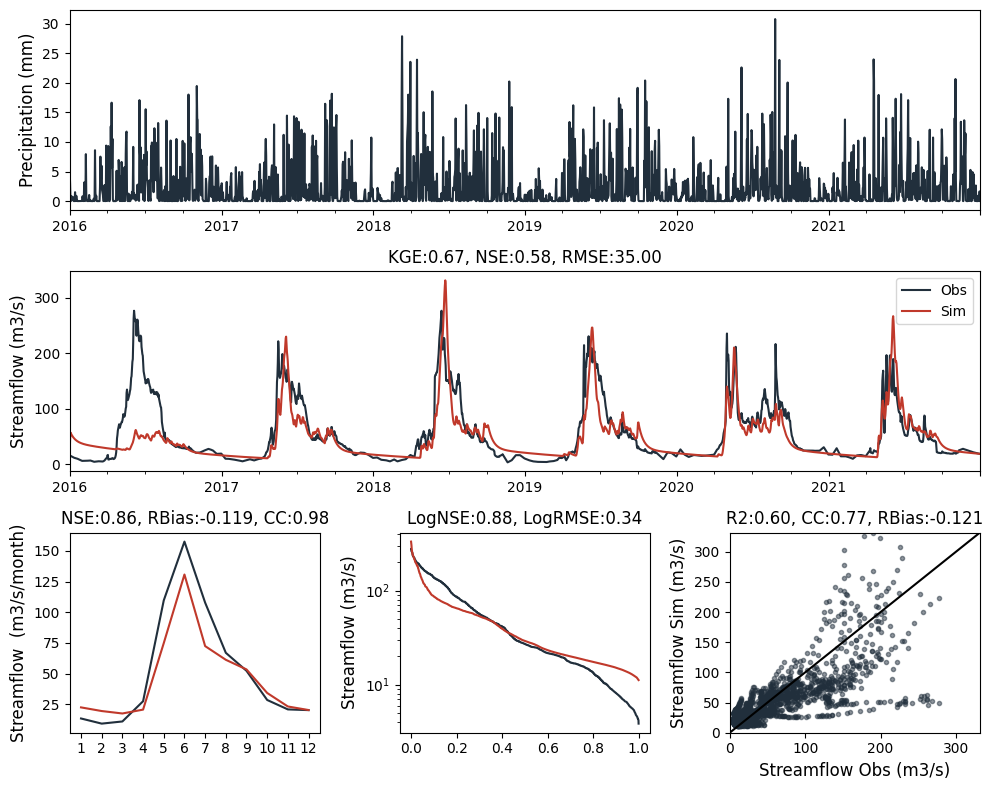

In [22]:
metrics_val, val= validation(hydro_data, val_date_start_minus_one, val_date_end, area, lat, p_good)

# Чистка датафрейма с валидацией

In [23]:
df_hydro_validation = pd.DataFrame()
df_hydro_validation["Observed values"] =  hydro_data.loc[val_date_start_minus_one:val_date_end].qt
df_hydro_validation["Simulated values"] =  val.loc[val_date_start_minus_one:val_date_end].qt
df_hydro_validation = df_hydro_validation[val_date_start_minus_one.replace(year=val_date_start_minus_one.year + 1):]
df_hydro_validation = df_hydro_validation.dropna()
df_hydro_validation = df_hydro_validation[df_hydro_validation["Simulated values"] != np.inf]
df_hydro_validation = df_hydro_validation[df_hydro_validation["Simulated values"] > -np.inf]

# Экспорт валидации в эксель

In [30]:
df_hydro_validation.to_excel(f"result/con/{hydro_post_data.loc[hydro_post_data["ids"] == index_hydro]["name"].values[0]}({index_hydro}) NSE ВАЛИДАЦИЯ MC ДЛЯ СТАТЬИ РЕОНАЛИЗ 2017 по 2021.xlsx")

# Метрики при валидации

In [25]:
metrics_validation = {
    "NSE" : round(float((he.evaluator(he.nse, df_hydro_validation["Simulated values"].values, df_hydro_validation["Observed values"].values))[0]), 2), 
    "KGE": round(float((he.evaluator(he.kge, df_hydro_validation["Simulated values"].values, df_hydro_validation["Observed values"].values))[0]), 2),
    "RMSE": round(root_mean_squared_error(df_hydro_validation["Observed values"].values, df_hydro_validation["Simulated values"].values), 2),
    "MAE": round(mean_absolute_error(df_hydro_validation["Observed values"].values, df_hydro_validation["Simulated values"].values), 2),
}
metrics_validation = pd.DataFrame.from_dict([metrics_validation])
metrics_validation

,NSE,KGE,RMSE,MAE
0,0.76,0.83,25.19,15.54


# Визуализация при валидационном периоде

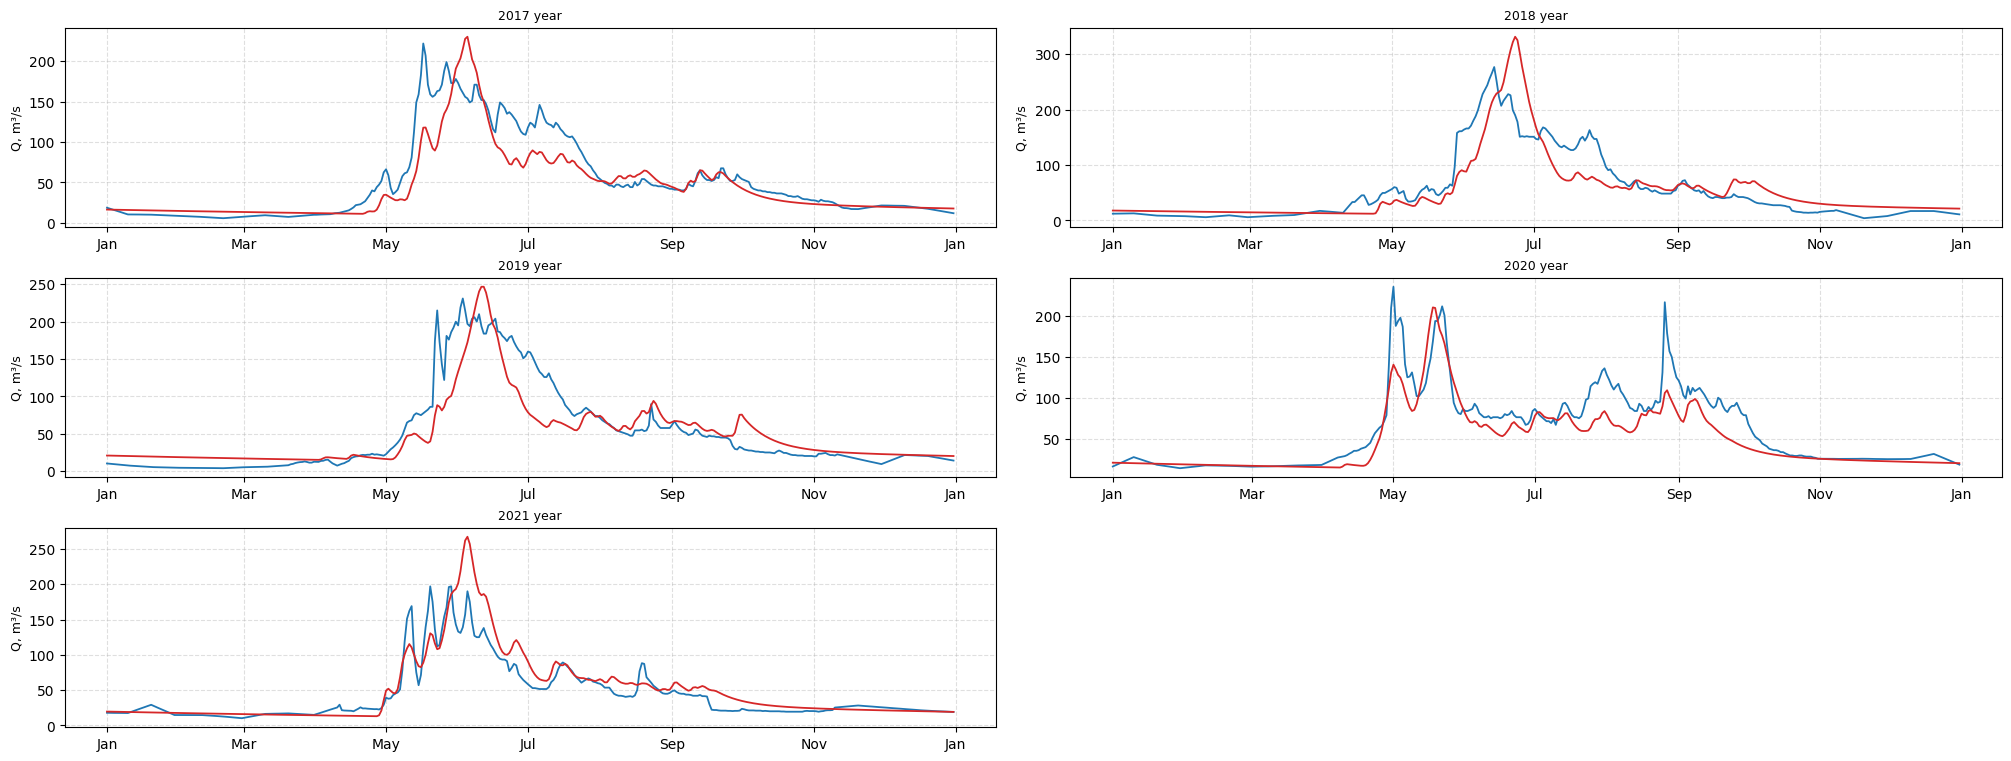

In [26]:
numeric_cols = ['Observed values', 'Simulated values']
years = sorted(df_hydro_validation.index.year.unique())

# Оптимальное количество колонок
ncols = 2
nrows = (len(years) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, 
    figsize=(20, nrows*2.5), 
    constrained_layout=True
)

# fig.suptitle('Калибровка ЭКОМАГ', fontsize=16, y=1.02)
date_format = mdates.DateFormatter("%b")

# Заглушки для легенды
lines = []
for col in numeric_cols:
    line, = axes.flat[0].plot([], [], label=col)
    lines.append(line)

# Отрисовка графиков
for i, year in enumerate(years):
    ax = axes.flat[i]
    year_data = df_hydro_validation[df_hydro_validation.index.year == year]

    ax.plot(year_data['Observed values'], color="#1f77b4", linewidth=1.3)
    ax.plot(year_data['Simulated values'], color="#d62728", linewidth=1.3)
    ax.set_ylabel("Q, m³/s", fontsize=9)
    ax.set_title(f'{year} year', fontsize=9)
    ax.xaxis.set_major_formatter(date_format)
    ax.grid(True, linestyle='--', alpha=0.4)

# Убираем пустые оси
for j in range(i+1, nrows*ncols):
    fig.delaxes(axes.flat[j])

# Легенду переносим вниз
# fig.legend(
#     handles=lines,
#     labels=numeric_cols,
#     loc='upper left',
#     ncol=2,
#     frameon=False,
#     fontsize=12
# )
# Добавляем отступ снизу под легенду
plt.subplots_adjust(bottom=0.10)

# plt.savefig("annual_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()